# Resource benchmarking of nf-core/mag v5

Six supplementary figures comparing resource use across analysis stages and tools.
Results combine two datasets and two assembly modes.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from mag_bench import figures as fg
from mag_bench.build import prepare

DATA = "../data"
frames = prepare(DATA)


### Figure 1. Compute use by analysis stage

CPU core-hours per job (left), jobs launched per sample (middle), and total CPU core-hours per sample (right). Analysis stages group the main tools with their associated supporting jobs, so job counts do not necessarily equal the number of tools run. Points represent individual jobs; summary bars pool both datasets, with ranges showing dataset-specific estimates.


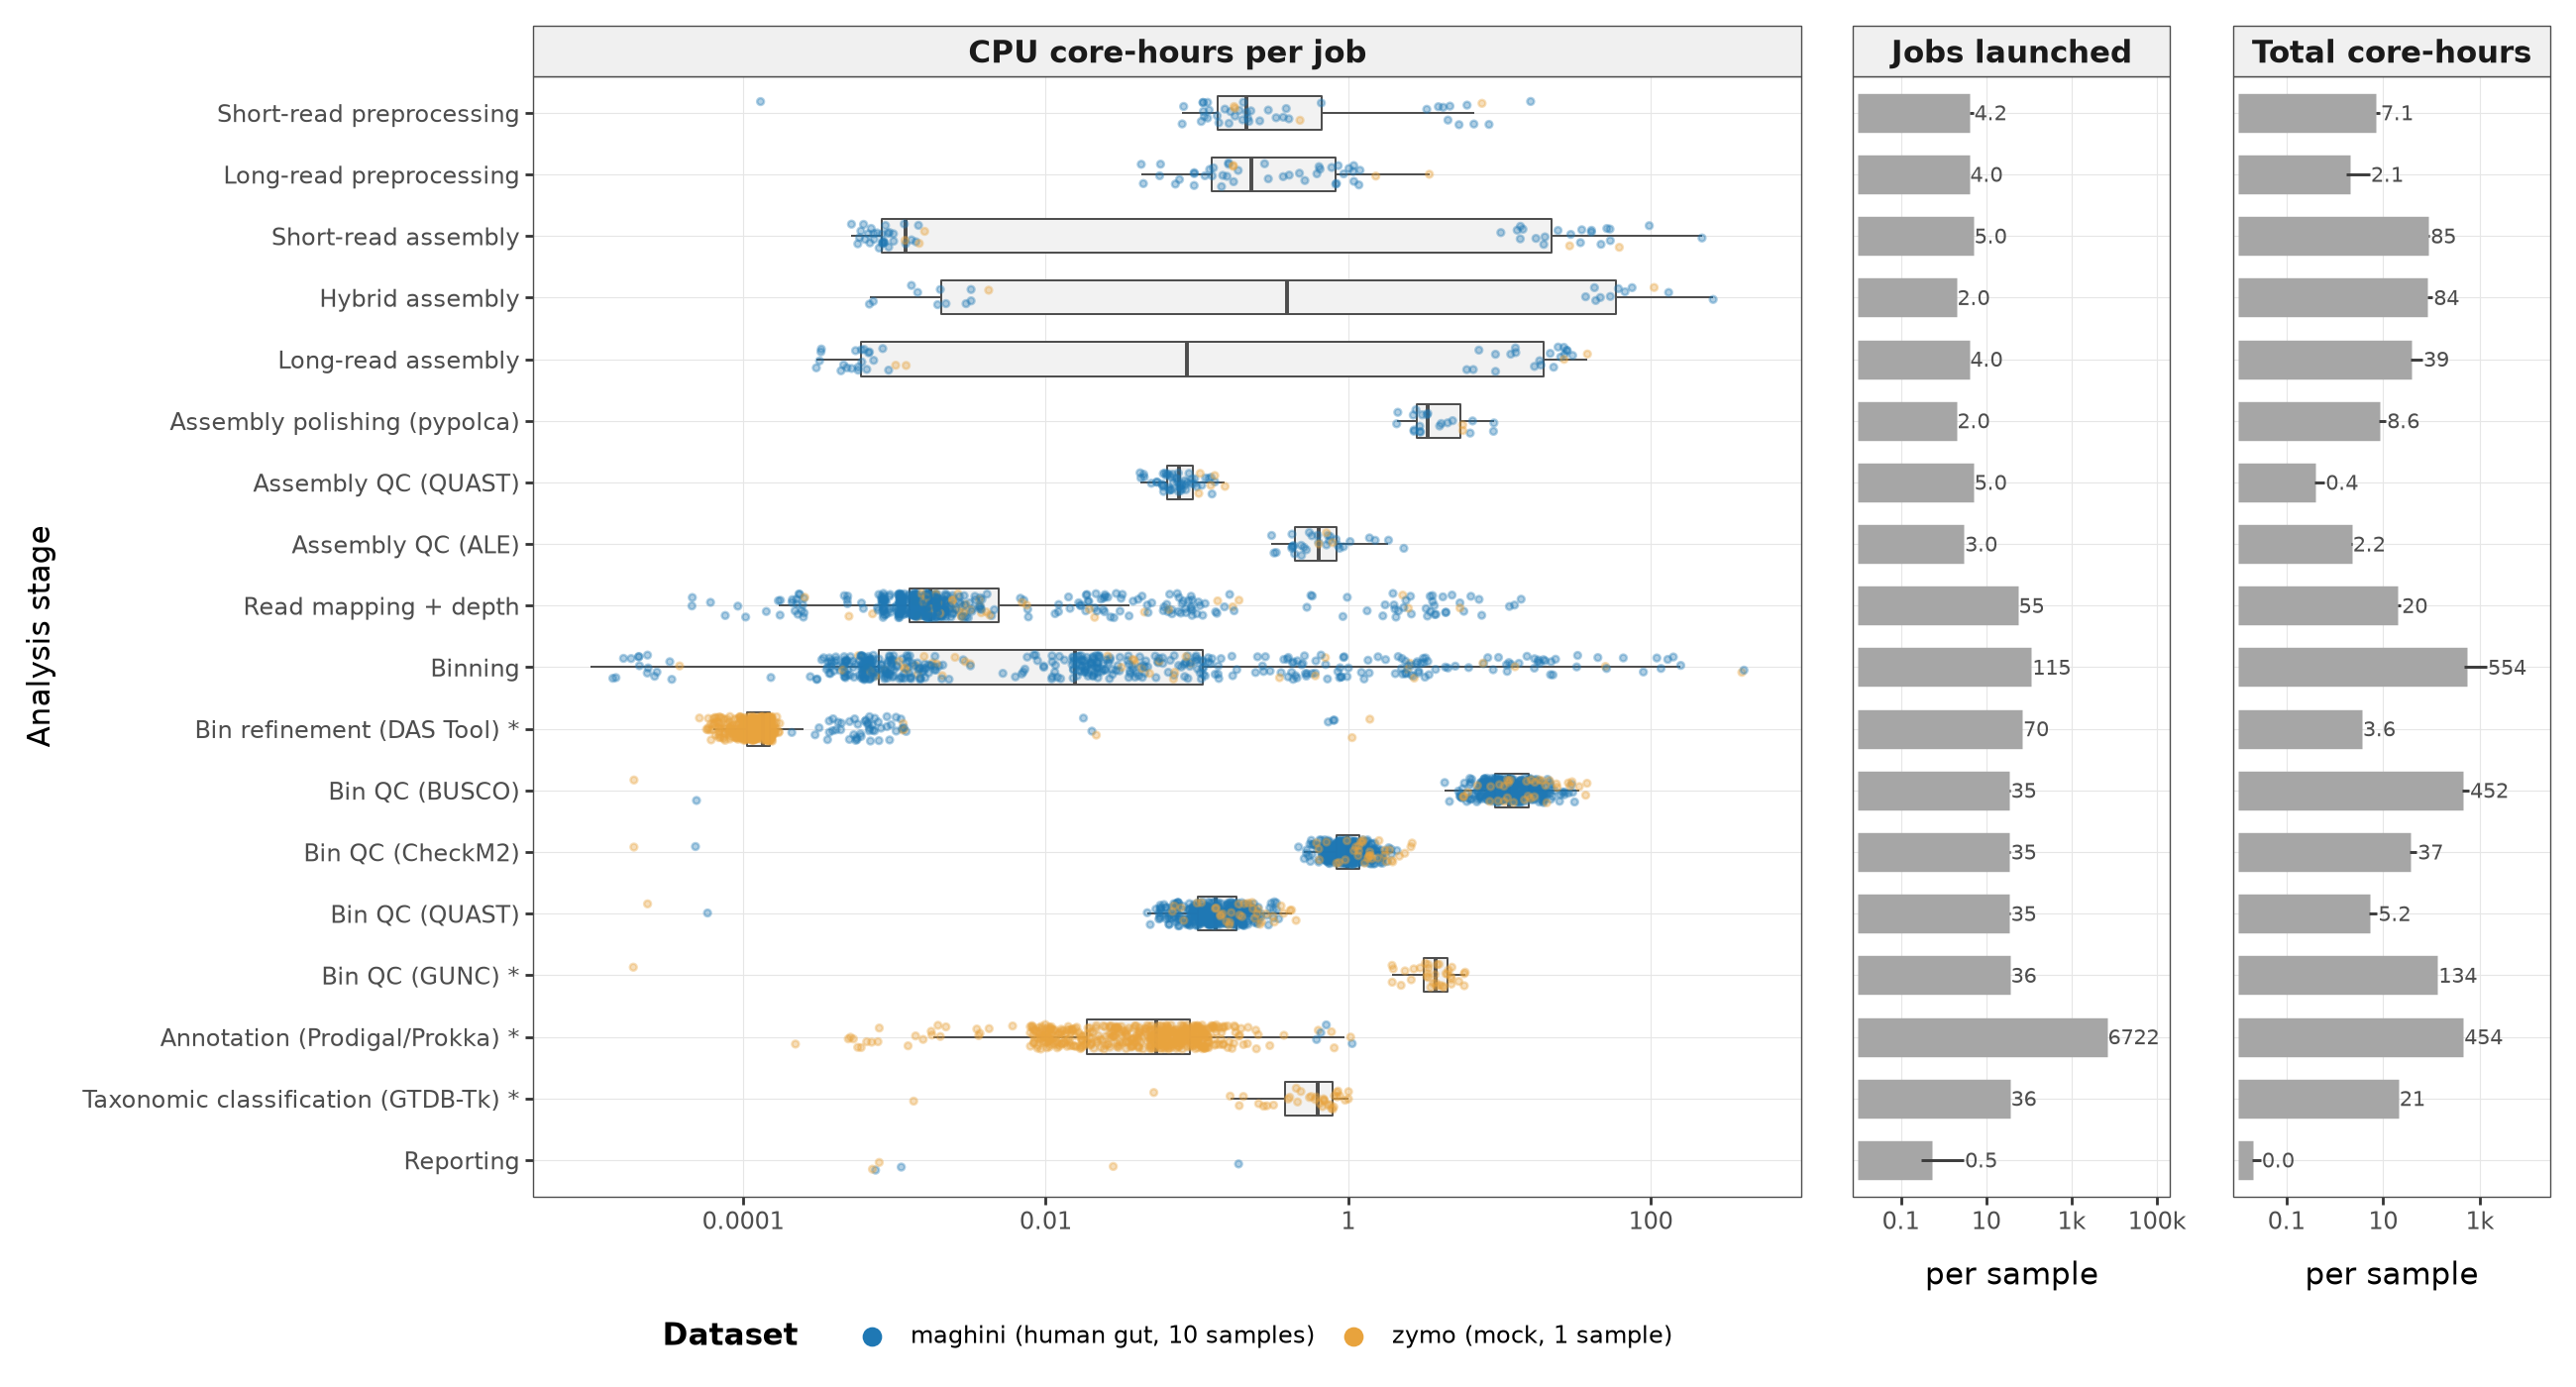

In [2]:
fg.fig_stage_compute(frames["budget"], frames["trace"])


### Figure 2. Storage per analysis stage

Data written and retained in the work directory by each analysis stage, expressed per sample. Analysis stages group the main tools with their associated supporting jobs, so job counts do not necessarily equal the number of tools run. Written data includes temporary files that may be removed before workflow completion. Points represent samples; boxes summarise groups with sufficient observations.


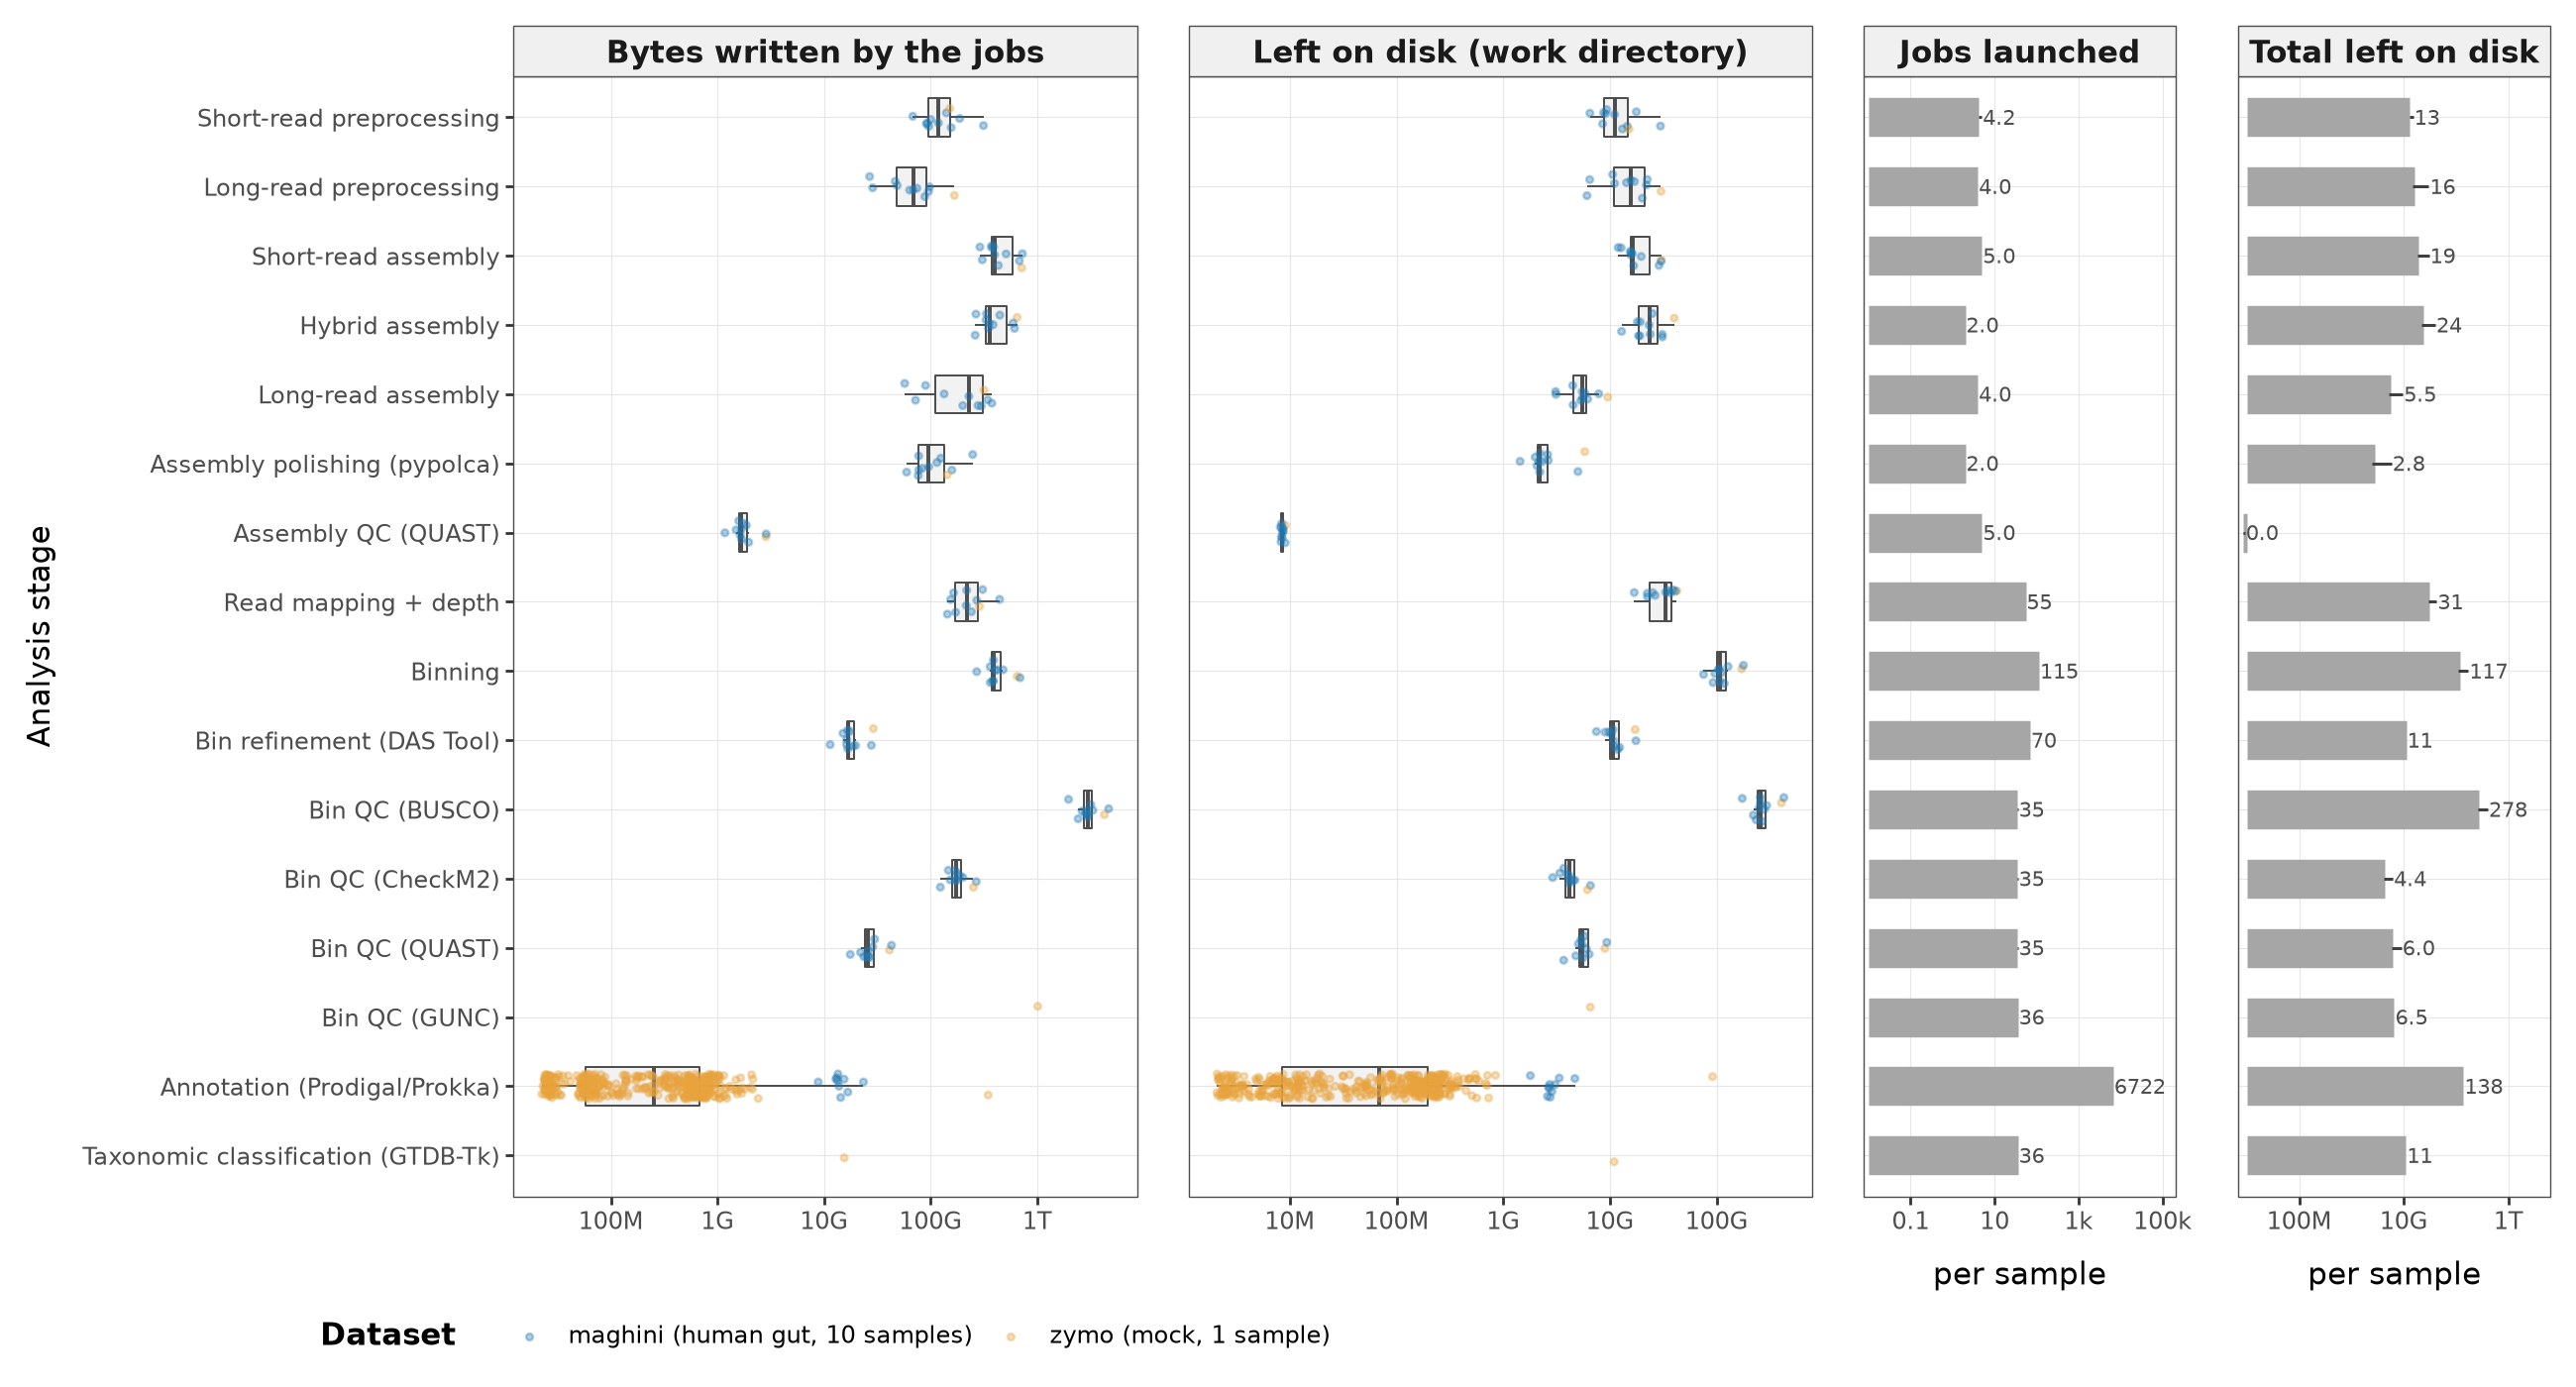

In [3]:
fg.fig_storage(frames["budget"], frames["storage"], frames["storage_budget"])

### Figure 3. Resource footprint per assembler and binner

Peak memory, wall-clock time, and CPU core-hours for assemblers (top) and binners (bottom). Points represent individual assemblies or assembly–binner combinations; boxes summarise groups with sufficient observations. Rows use independent scales.


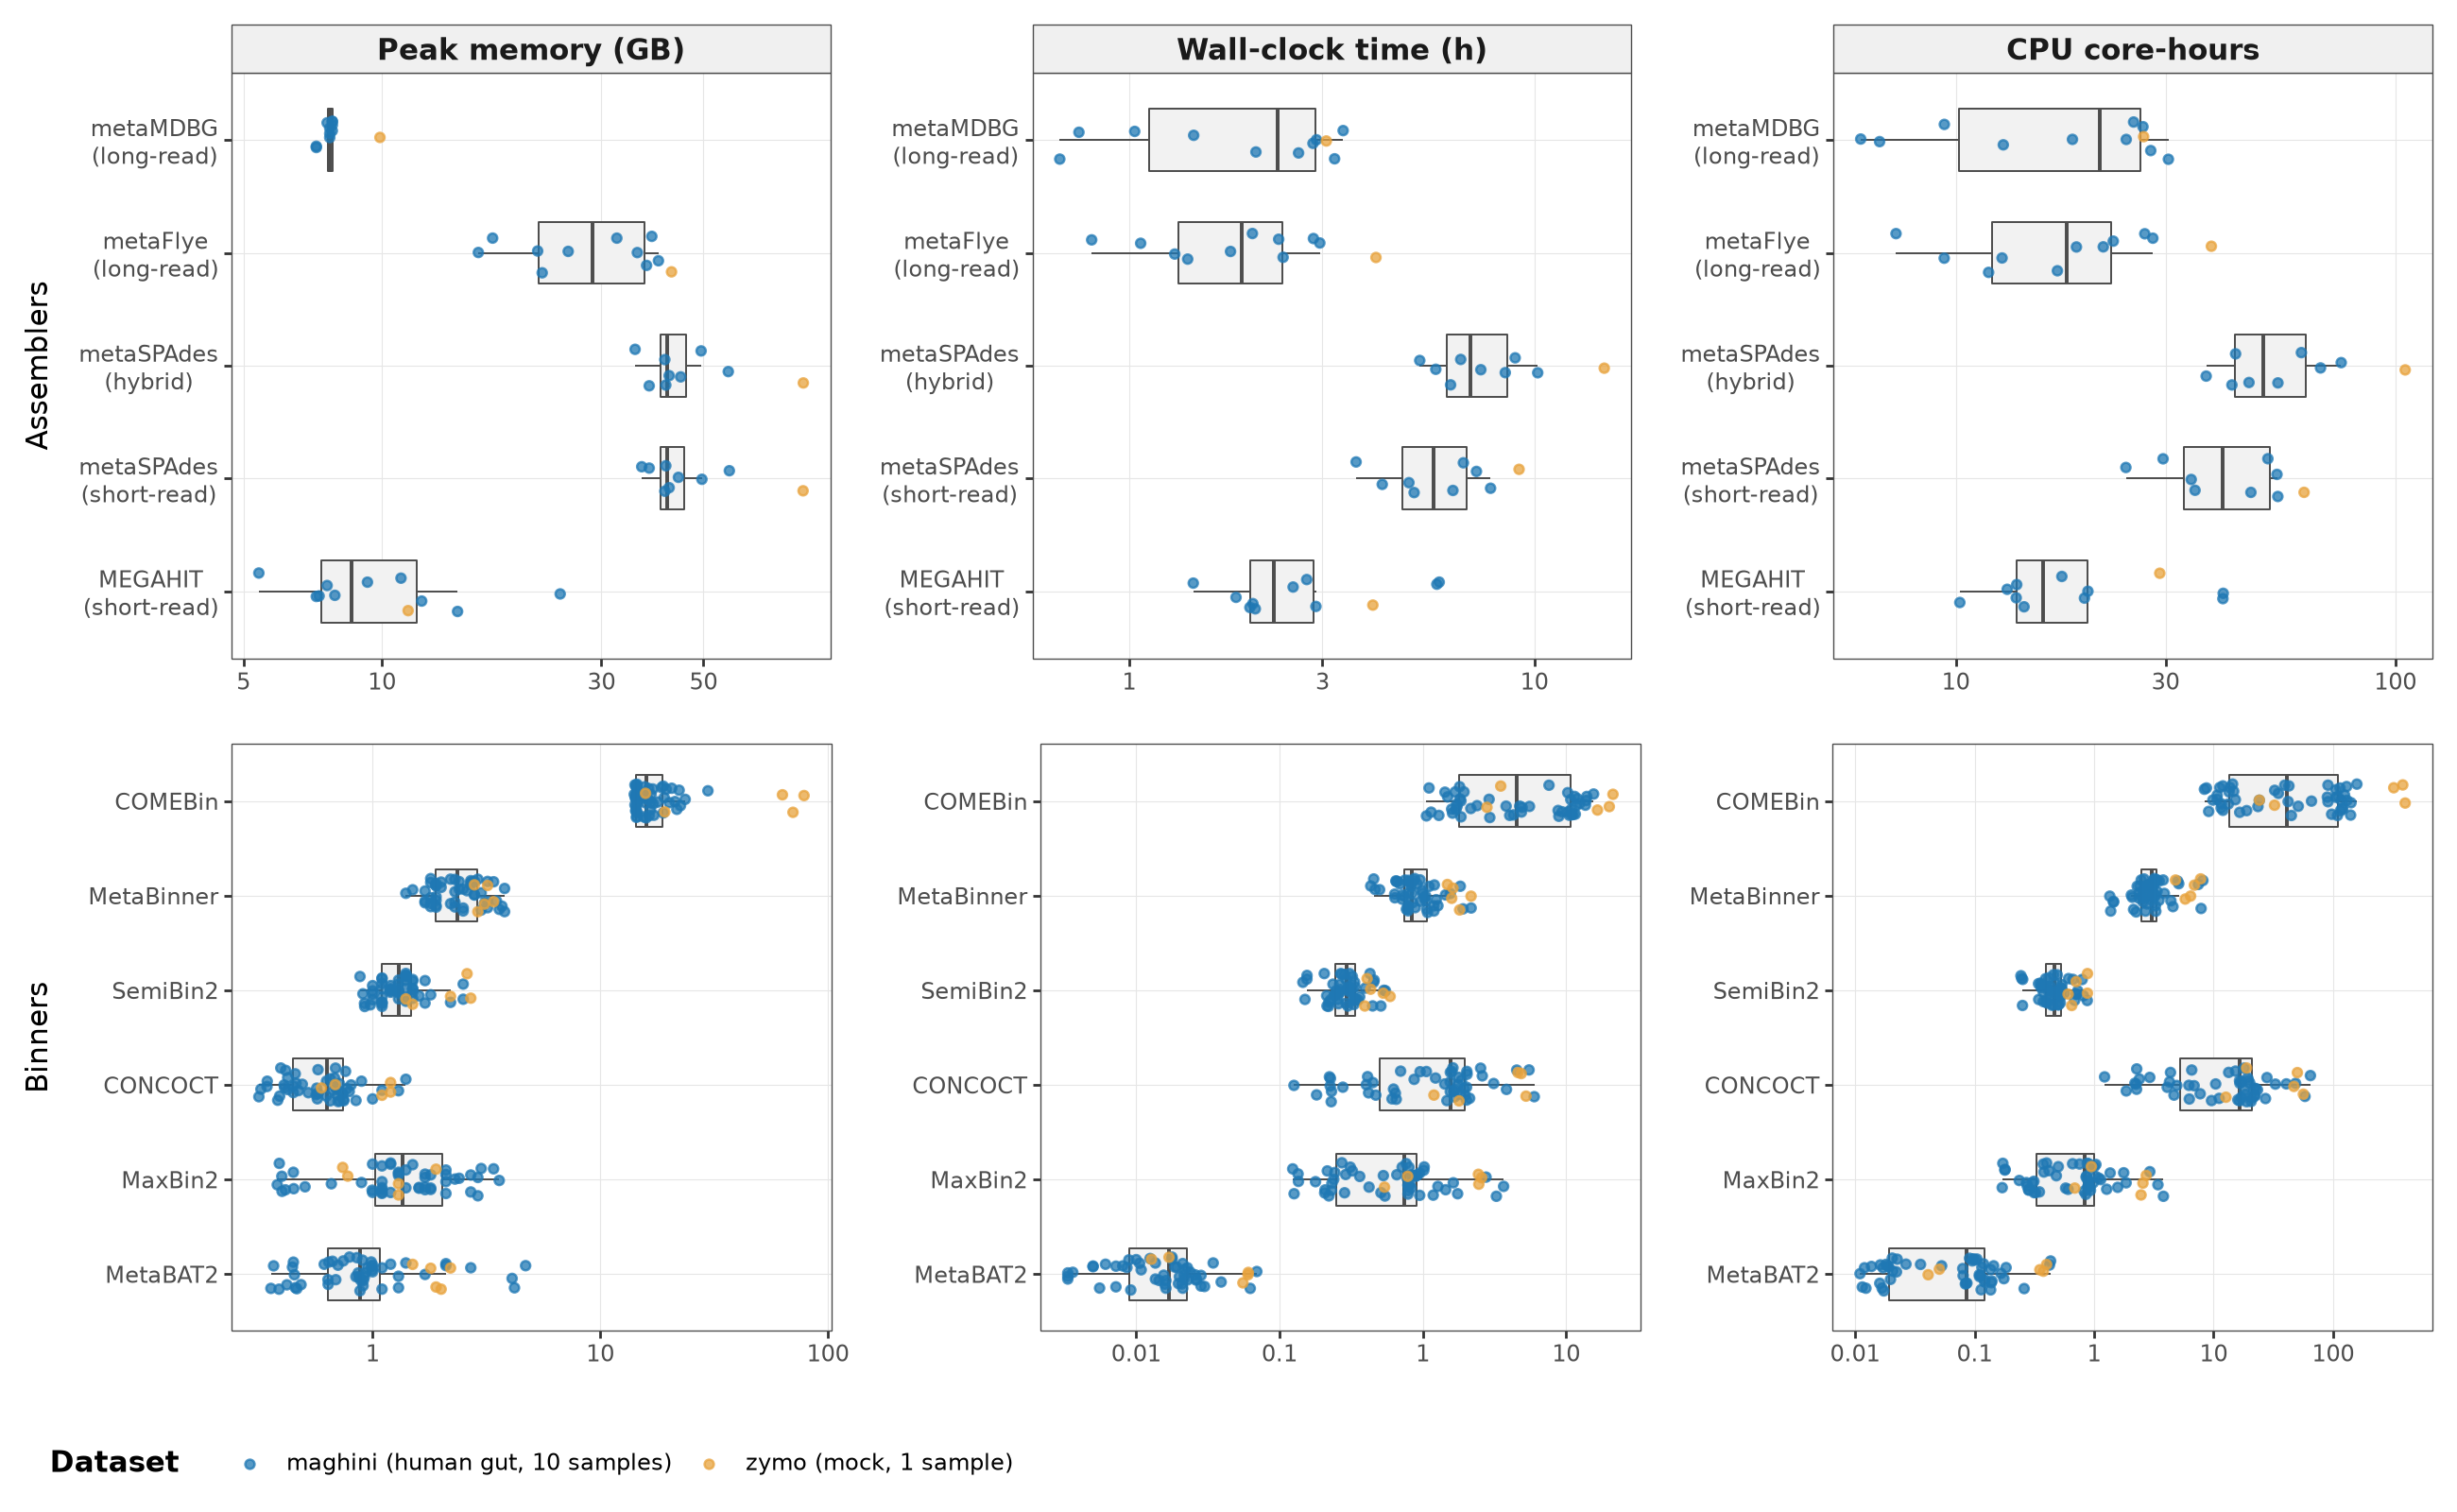

In [4]:
fg.fig_tool_footprint(frames["tasks"])

### Figure 4. Most resource-intensive processes per job

Processes with the highest median wall-clock time, peak memory, or work-directory size per job. Processes are ordered by their best rank across the three resources; labels report job counts. Time and memory use logarithmic scales.


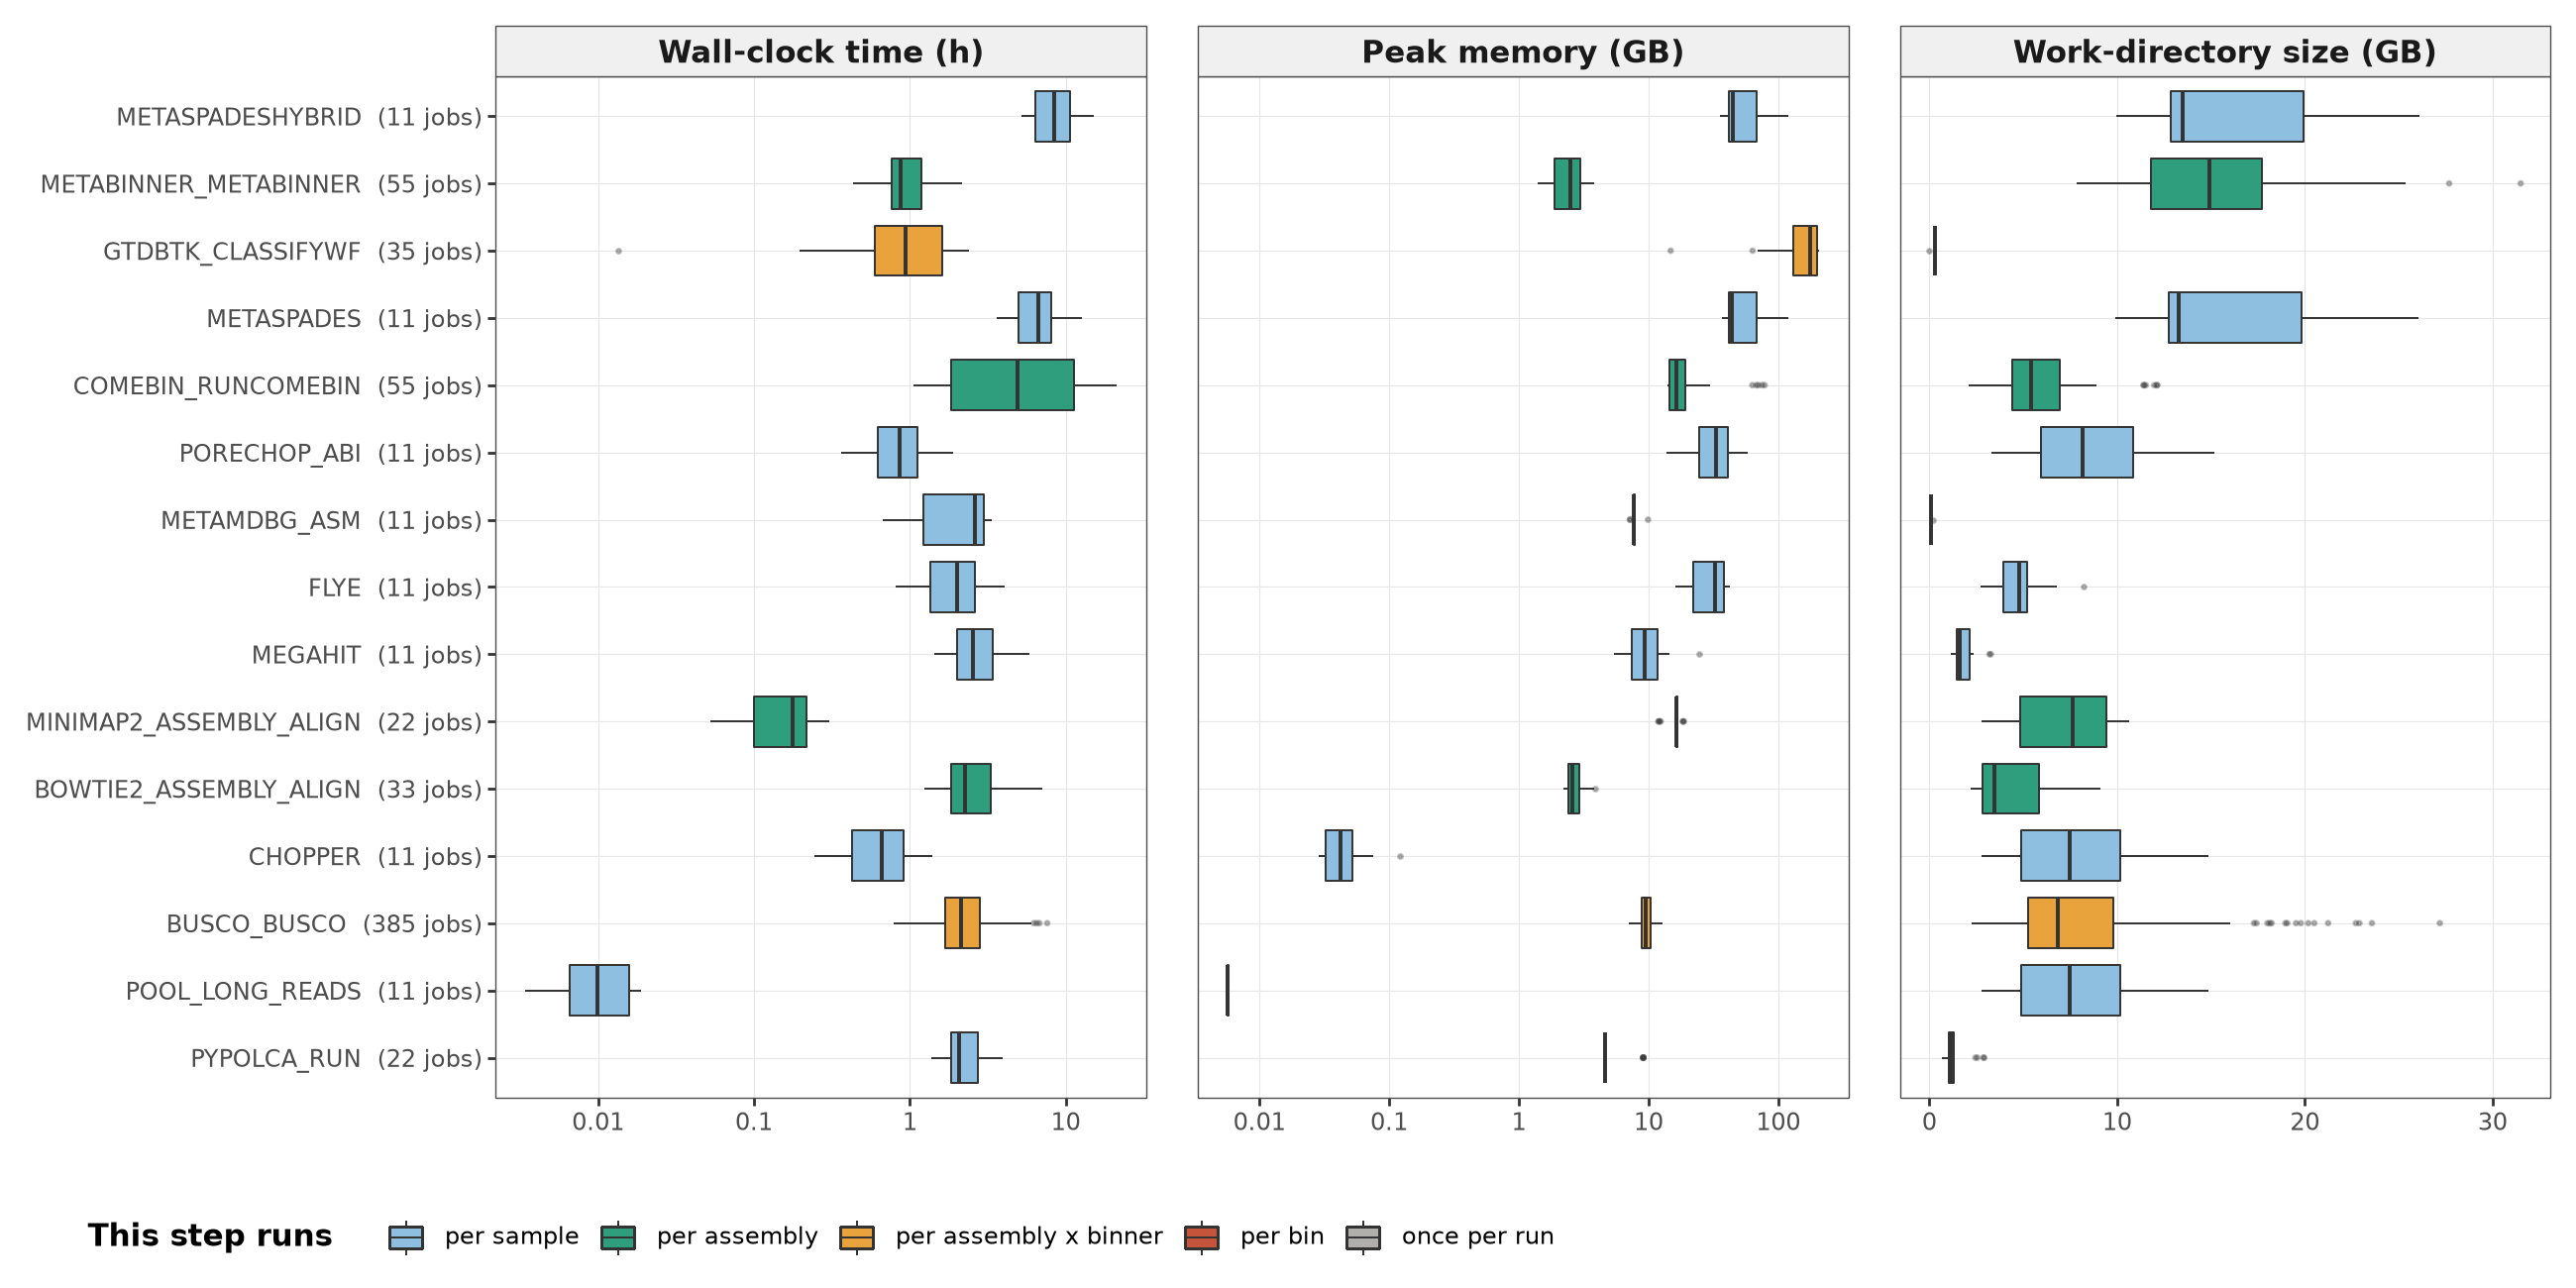

In [5]:
fg.fig_top_processes(frames["trace"])


### Figure 5. Assembler scaling with sequencing input

Assembler peak memory and CPU core-hours as a function of sequencing input. Input corresponds to short reads, long reads, or their sum according to the assembler. Points represent samples; grey bands show linear fits on log–log scales.


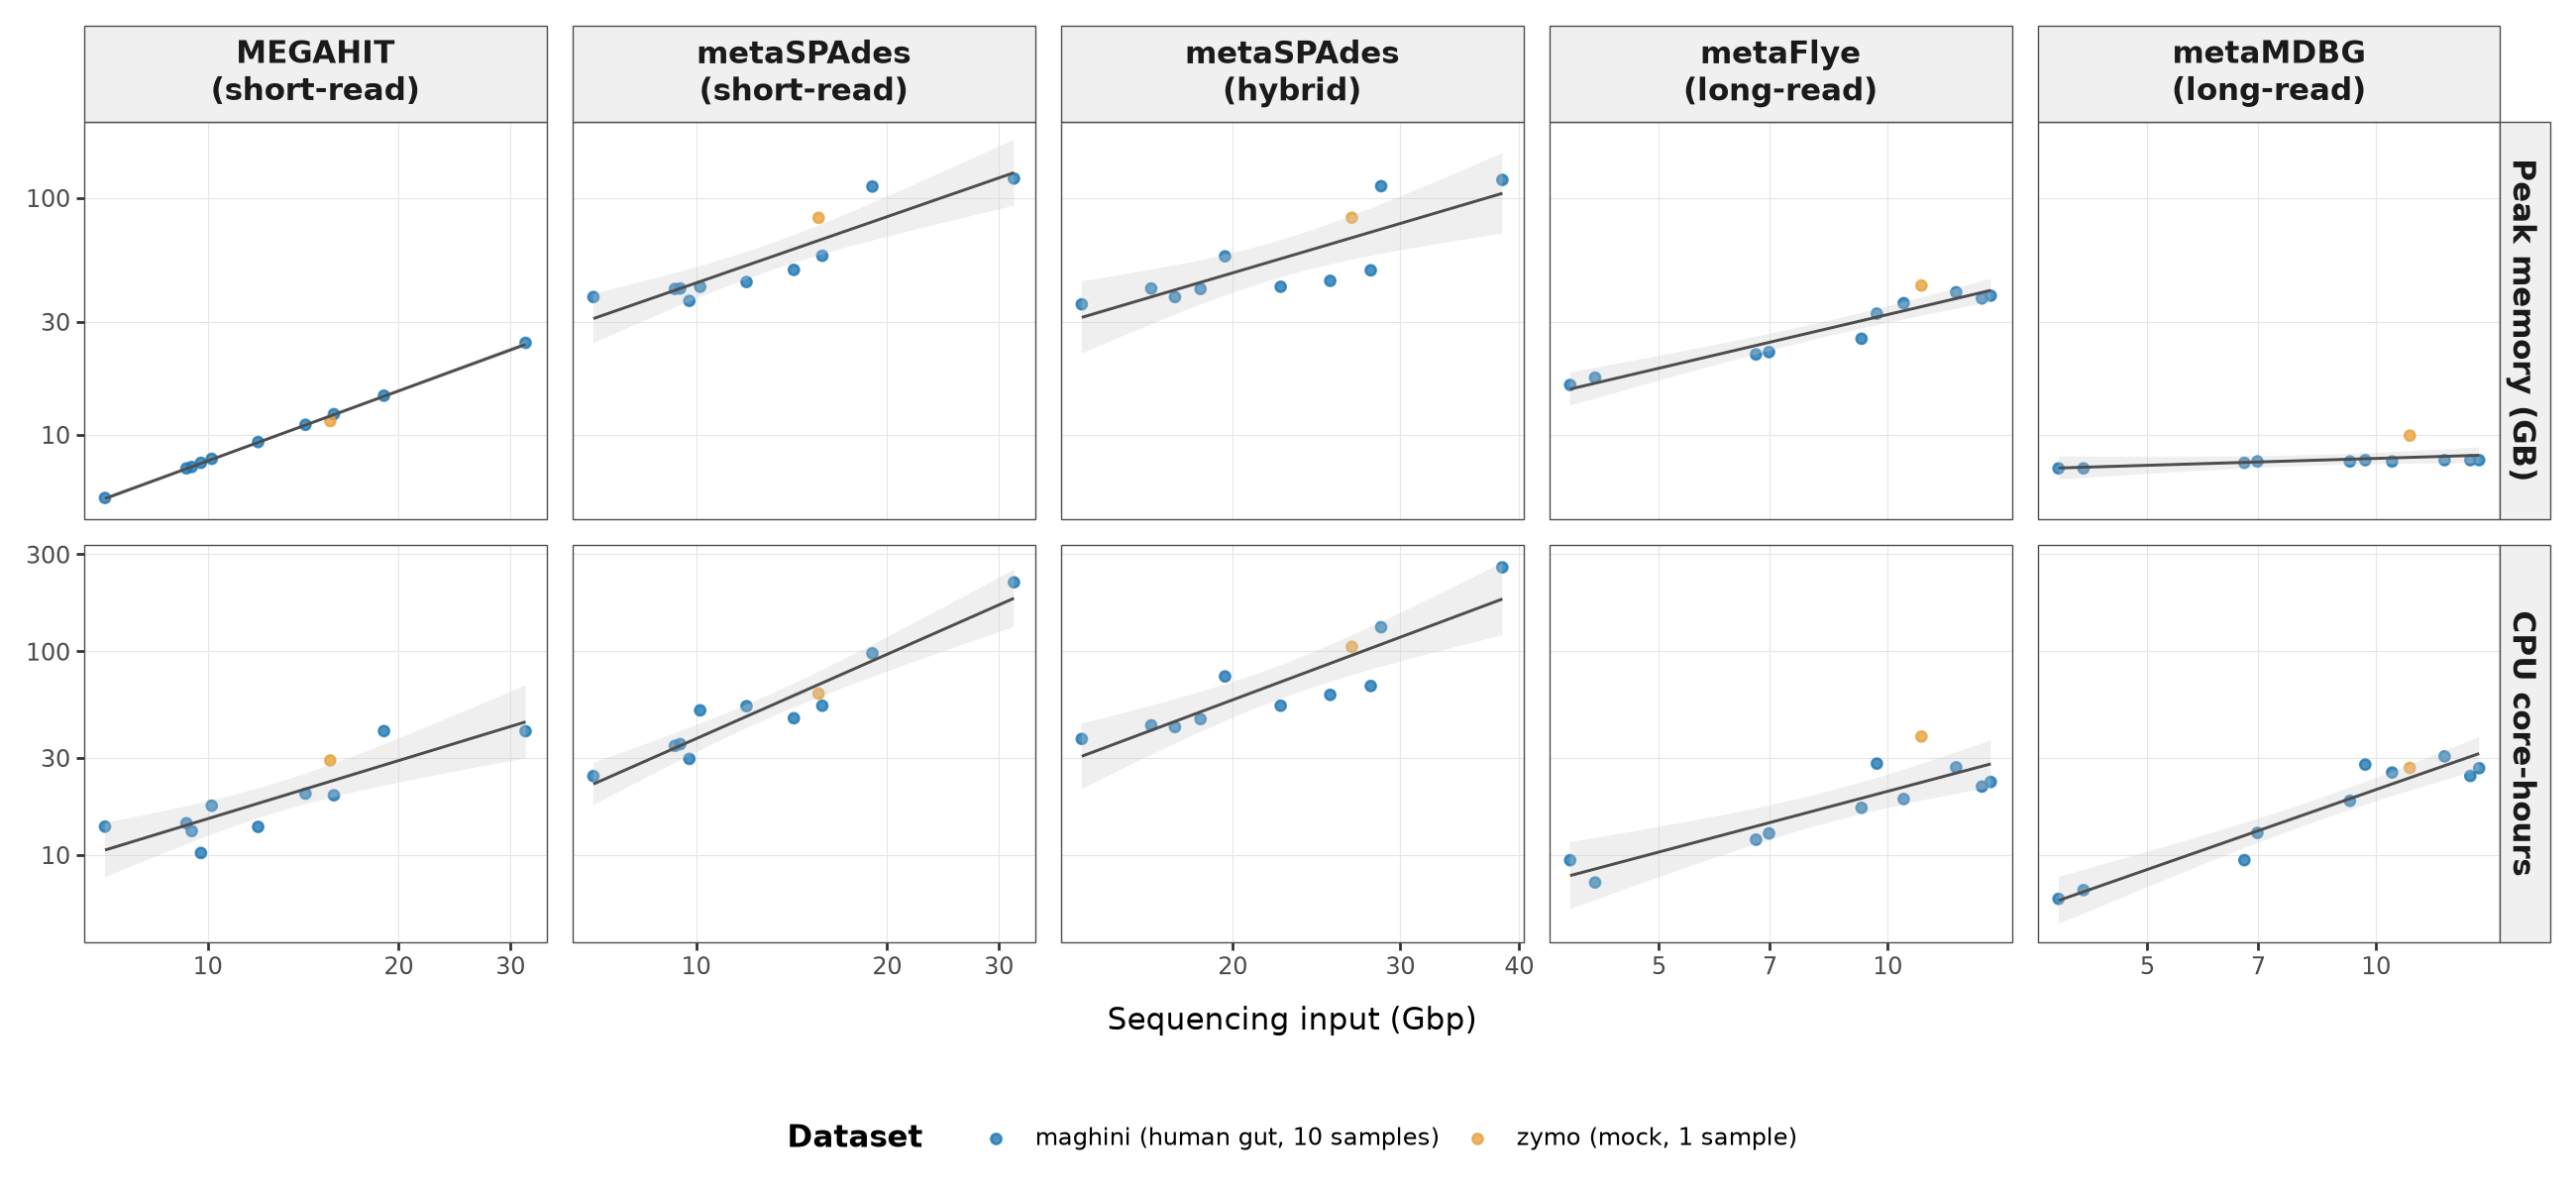

In [6]:
fg.fig_scaling_assemblers(frames["scaling"])


### Figure 6. Binner scaling with assembly size

Binner peak memory and CPU core-hours as a function of input assembly size. Points represent assembly–binner combinations; grey bands show linear fits on log–log scales. The x axis is shared across tools.


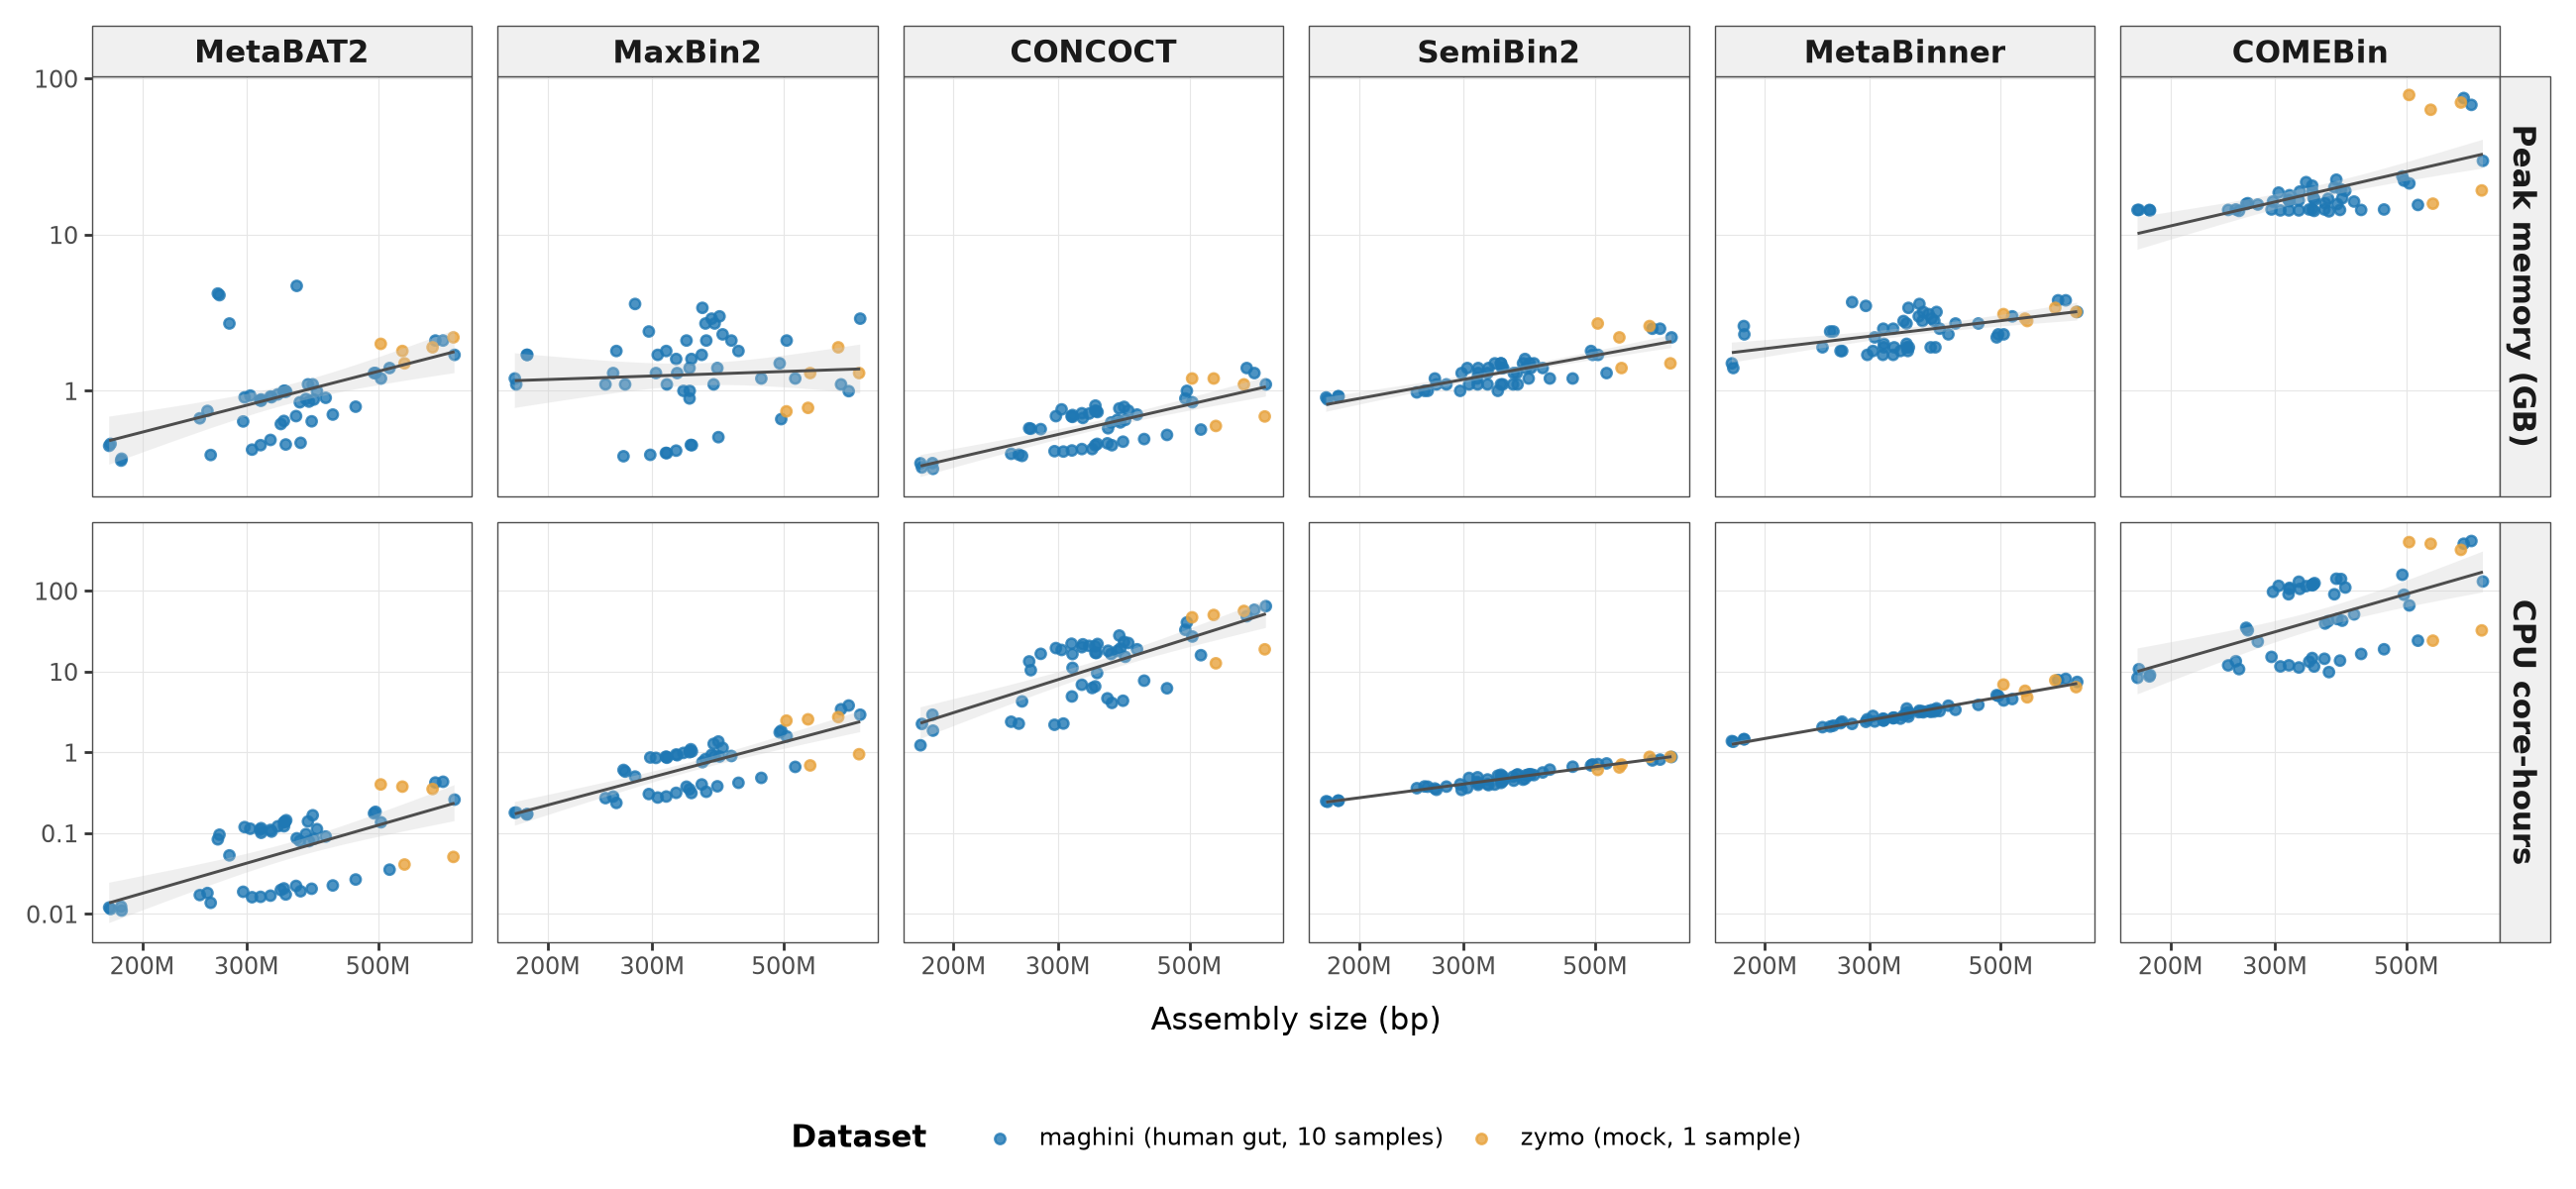

In [7]:
fg.fig_scaling_binners(frames["scaling"])

## Export


In [8]:
from mag_bench.build import build_all, save_all

save_all(build_all(DATA), out_dir="../figures", format="pdf")


../figures/S1_stage_compute.pdf  (1.4s)
../figures/S2_storage.pdf  (1.2s)
../figures/S3_tool_footprint.pdf  (1.4s)
../figures/S4_top_processes.pdf  (1.1s)
../figures/S5_scaling_assemblers.pdf  (0.7s)
../figures/S6_scaling_binners.pdf  (0.6s)


[PosixPath('../figures/S1_stage_compute.pdf'),
 PosixPath('../figures/S2_storage.pdf'),
 PosixPath('../figures/S3_tool_footprint.pdf'),
 PosixPath('../figures/S4_top_processes.pdf'),
 PosixPath('../figures/S5_scaling_assemblers.pdf'),
 PosixPath('../figures/S6_scaling_binners.pdf')]